# Classificação: Primeiros passos

Neste projeto, iremos analisar dados de uma campanha de marketing para aderência de investimentos. O intuito é usar as informações dos dados para prever se os clientes de um banco vão aplicar o dinheiro em um investimento ou não.

Essa previsão será feita utilizando machine learning e este notebook vai conter os passos para se obter um modelo capaz de realizar as previsões, desde a **leitura**, **análise exploratória**, **separação** e **transformação** dos dados, até o **ajuste**, **avaliação** e **comparação** de modelos de classificação.

# Aula 1: Análise exploratória

## Fazendo a leitura dos dados

Podemos realizar a leitura dos dados a partir da biblioteca `pandas`. Por conta disso, vamos realizar a importação da biblioteca com o comando `import pandas as pd`.

Como o arquivo de dados está no formato *csv*, vamos realizar a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [67]:
import pandas as pd

In [68]:
dados = pd.read_csv('/content/marketing_investimento.csv')
dados

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim
...,...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6,sim
1264,35,solteiro (a),superior,nao,5958,nao,215,1,sim
1265,30,solteiro (a),superior,nao,-477,sim,1532,2,sim
1266,42,casado (a),superior,nao,2187,nao,525,3,sim


In [69]:
dados['estado_civil'].value_counts()

estado_civil
casado (a)        738
solteiro (a)      368
divorciado (a)    162
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

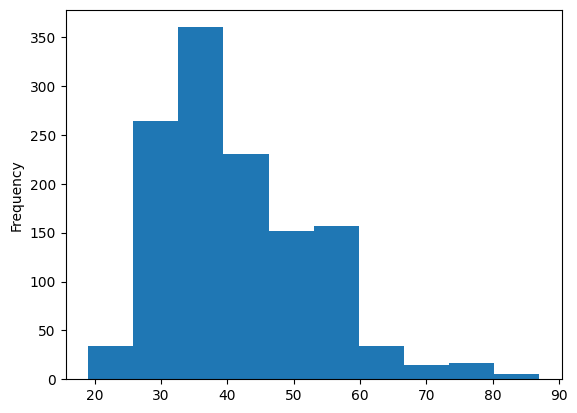

In [70]:
dados['idade'].plot(kind='hist')

Para criar modelos de classificação, precisamos utilizar dados de qualidade, sem inconsistências e sem dados faltantes. Vamos checar se existem dados nulos e o tipo dos dados de cada coluna na base de dados a partir do método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [71]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


## Explorando os dados

Uma etapa muito importante em projetos de machine learning é a exploração e entendimento dos dados, conhecida como **análise exploratória**. Podemos utilizar gráficos para verificar quais são as informações em cada uma das colunas da base de dados, identificar inconsistências e padrões que possam existir.

Vamos explorar cada uma das colunas da base de dados com o uso da biblioteca `plotly`. Vamos começar pelas variáveis categóricas e depois explorar as variáveis numéricas.

### Variáveis categóricas

In [72]:
import plotly.express as px

In [73]:
px.histogram(dados, x = 'aderencia_investimento', text_auto = True)

In [74]:
px.histogram(dados, x = 'estado_civil', text_auto = True, color = 'aderencia_investimento', barmode = 'group')

In [75]:
px.histogram(dados, x = 'escolaridade', text_auto = True, color = 'aderencia_investimento', barmode = 'group')

In [76]:
px.histogram(dados, x = 'inadimplencia', text_auto = True, color = 'aderencia_investimento', barmode = 'group')

In [77]:
px.histogram(dados, x = 'fez_emprestimo', text_auto = True, color = 'aderencia_investimento', barmode = 'group')

### Variáveis numéricas

In [78]:
px.box(dados, x = 'idade', color = 'aderencia_investimento')

In [79]:
px.box(dados, x = 'saldo', color = 'aderencia_investimento')

In [80]:
px.box(dados, x = 'tempo_ult_contato', color = 'aderencia_investimento')

In [81]:
px.box(dados, x = 'numero_contatos', color = 'aderencia_investimento')

Conclusão: Não precisamos fazer nenhum tratamento nos dados pois não temos discrepâncias irreais, dados nulos ou quaisquer dados que necessitem ser retirados.

# Aula 2: Transformação de dados

Obtendo a columa alvo e as demais

In [82]:
x = dados.drop('aderencia_investimento', axis = 1)
y = dados['aderencia_investimento']

As variáveis explicativas serão transformadas em numéricas usando one hot encoding, não usaremos 1, 2 ou 3 para evitar hierarquizar as variáveis. Algumas observações:
- O if_binary na opção drop diz para jogar fora uma das colunas caso tenham só duas categorias, um exemplo disso é no caso da coluna fez_emprestimo porque ela tem só sim e não.
- no make_column_transformer, o parâmetro remainder é para saber o que fazer com as colunas que não estão listadas após o método OneHotEncoder, estamos especificando 'passthrough' para instruir a não remover as demais colunas.

In [83]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [84]:
colunas = x.columns

In [85]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo']
),
    remainder = 'passthrough',
    sparse_threshold = 0)

In [86]:
x = one_hot.fit_transform(x)

In [87]:
# Esse método retorna qual nome novo das colunas
feature_names = one_hot.get_feature_names_out(colunas)
feature_names

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

In [88]:
# Os nomes das colunas estão muito complicados. Estou simplificando os nomes.
def simplify_names(feature_names):
  simplified_names = []
  for name in feature_names:
      if 'onehotencoder__' in name:
          simplified_names.append('onehot_' + name.split('__')[1].replace(' (a)', ''))
      else:
          simplified_names.append(name.split('__')[1])
  return simplified_names;

In [89]:
simplified_names = simplify_names(feature_names)
pd.DataFrame(x, columns = simplified_names)

,onehot_estado_civil_casado,onehot_estado_civil_divorciado,onehot_estado_civil_solteiro,onehot_escolaridade_fundamental,onehot_escolaridade_medio,onehot_escolaridade_superior,onehot_inadimplencia_sim,onehot_fez_emprestimo_sim,idade,saldo,tempo_ult_contato,numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


## Transformando a variável alvo

Para isso usaremos o método específico LabelEncoder, a explicação do instrutor é que será usada uma biblioteca diferente porque esse encoder estará sendo usado para uma variável que será usada somente no treinamento e nada mais, o OneHotEncoder por sua vez será usada em um modelo que processará mais dados além dos que serão usados no treinamento.

In [90]:
from sklearn.preprocessing import LabelEncoder

In [91]:
label_encoder = LabelEncoder()

In [92]:
y = label_encoder.fit_transform(y)

In [93]:
y

array([1, 1, 0, ..., 1, 1, 1])

# Aula 3: Ajustando modelos


## Divisão de treino e teste

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
# o Stratify informa que queremos manter a proporção
# padrão é pegar 25% dos dados para teste
# random_state permite que o meu teste e o seu tenham os mesmos resultados
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, random_state = 5)

## Modelo de base

Se baseia em decisões simples tomadas pelo agoritmo, separando os dados com base em comparações de menor e maior nos valores das colunas da base de dados.

In [96]:
from sklearn.dummy import DummyClassifier

In [97]:
dummy = DummyClassifier()
dummy.fit(x_train, y_train)

dummy.score(x_test, y_test)

0.6025236593059937

## Árvore de decisão

In [98]:
from sklearn.tree import DecisionTreeClassifier

In [99]:
arvore = DecisionTreeClassifier(random_state = 5)
arvore.fit(x_train, y_train)

DecisionTreeClassifier(random_state=5)

In [100]:
arvore.predict(x_test)

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,

In [101]:
arvore.score(x_test, y_test)

0.6656151419558359

In [102]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [103]:
nome_colunas = ['casado (a)',
                'divorciado (a)',
                'solteiro (a)',
                'fundamental',
                'medio',
                'superior',
                'inadimplencia',
                'fez_emprestimo',
                'idade',
                'saldo',
                'tempo_ult_contato',
                'numero_contatos']


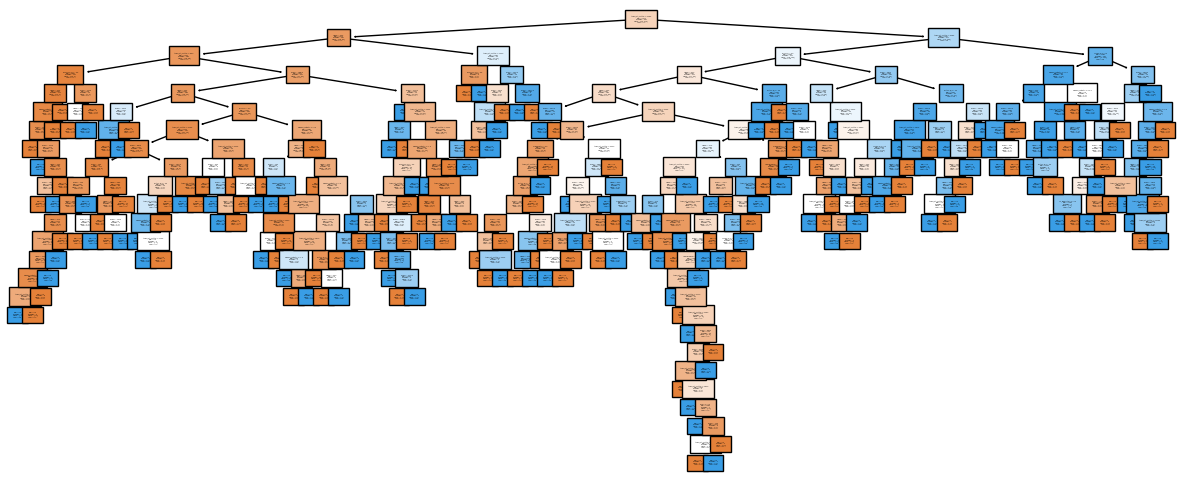

In [104]:
plt.figure(figsize = (15,6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 1, feature_names = nome_colunas);

A árvore se expandiu e calculou todas as possíveis saídas para os valores de entrada, se rodarmos a função score ela vai retornar 1.0 (ou seja, cem porcento), porém não é isso que queremos pois ela decorou as saídas com base nas entradas ao invés de construir o modelo que pegue os casos. Para resolver isso vamos usar novamente a função de árvore de decisão, porém agora usaremos max_depth = 3.

In [105]:
arvore = DecisionTreeClassifier(max_depth = 3, random_state = 5)
arvore.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=5)

In [106]:
arvore.score(x_train, y_train)

0.7613038906414301

In [107]:
arvore.score(x_test, y_test)

0.7160883280757098

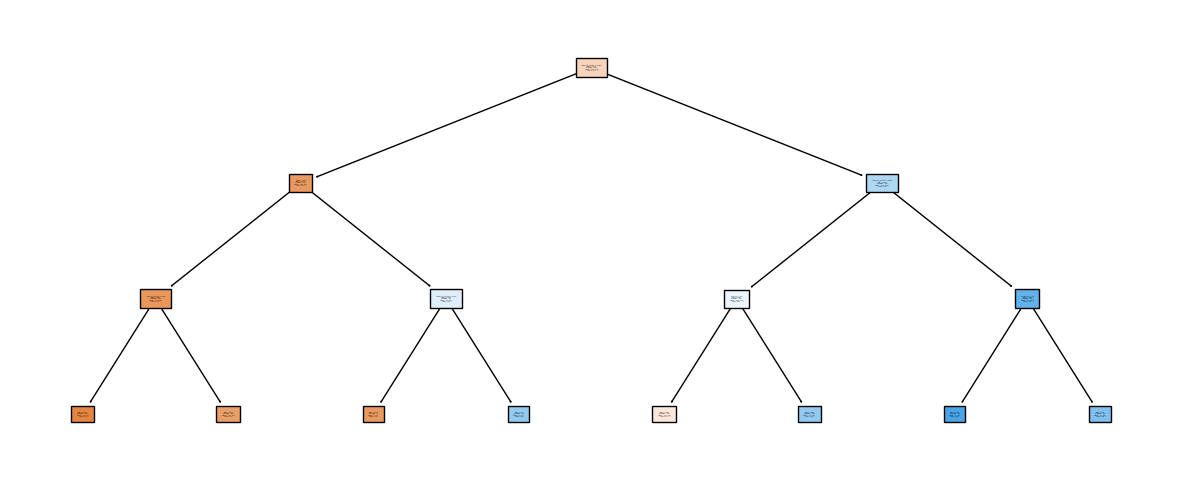

In [108]:
plt.figure(figsize = (15,6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 1, feature_names = nome_colunas);

# Aula 4: Seleção de modelos

## Normalizando dados

Faremos uma normalização dos dados para não haver deturpações. O exemplo que o professor citou em aula foi a existência da variável idade e a variável saldo, no caso específico apresentado a idade varia de 19 até 87, já o saldo varia de -1000 até 29000, o algoritmo KNN vai dar maior peso para a variável saldo ao calcular as distâncias por causa da dimensão dos números... para evitar casos como esse precisamos fazer a normalização.

In [109]:
from sklearn.preprocessing import MinMaxScaler

In [110]:
normalized = MinMaxScaler()
x_train_normalized = normalized.fit_transform(x_train)

In [111]:
pd.DataFrame(x_train_normalized)

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.205882,0.065564,0.123734,0.032258
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.147059,0.045792,0.396527,0.032258
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.076036,0.335022,0.000000
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.573529,0.062866,0.315123,0.000000
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.148380,0.065847,0.129032
...,...,...,...,...,...,...,...,...,...,...,...,...
946,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.191176,0.044265,0.246382,0.129032
947,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.205882,0.028043,0.275687,0.032258
948,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.323529,0.042952,0.024964,0.129032
949,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.176471,0.042810,0.023878,0.000000


## Utiliazando o KNN

In [112]:
from sklearn.neighbors import KNeighborsClassifier

In [113]:
knn = KNeighborsClassifier()

In [114]:
knn.fit(x_train_normalized, y_train)

KNeighborsClassifier()

In [115]:
x_test_normalized = normalized.transform(x_test)

In [116]:
knn.score(x_test_normalized, y_test)

0.6876971608832808

## Exportando o melhor modelo

In [117]:
print(f'Acurácia Dummy: {dummy.score(x_test, y_test)}')
print(f'Acurácia Arvore: {arvore.score(x_test, y_test)}')
print(f'Acurácia KNN: {knn.score(x_test_normalized, y_test)}')

Acurácia Dummy: 0.6025236593059937
Acurácia Arvore: 0.7160883280757098
Acurácia KNN: 0.6876971608832808


In [118]:
# Permite armazenar os modelos em arquivo serializado
import pickle

In [119]:
# wb é para dizer que escreverei bytes
with open('modelo_onehotenc.pkl', 'wb') as arquivo:
  pickle.dump(one_hot, arquivo)

In [120]:
with open('modelo_arvore.pkl', 'wb') as arquivo:
  pickle.dump(arvore, arquivo)

In [121]:
dados

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim
...,...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6,sim
1264,35,solteiro (a),superior,nao,5958,nao,215,1,sim
1265,30,solteiro (a),superior,nao,-477,sim,1532,2,sim
1266,42,casado (a),superior,nao,2187,nao,525,3,sim


In [128]:
novo_dado = {
    'idade': [45],
    'estado_civil':['solteiro (a)'],
    'escolaridade':['superior'],
    'inadimplencia': ['nao'],
    'saldo': [23040],
    'fez_emprestimo': ['nao'],
    'tempo_ult_contato': [800],
    'numero_contatos': [4]
}

In [129]:
novo_dado = pd.DataFrame(novo_dado)
novo_dado

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,solteiro (a),superior,nao,23040,nao,800,4


A biblioteca pickle é boa para armazenarmos o modelo que construímos da máquina em um arquivo e usar esse modelo para fazer as classificações. Faremos a leitura de um modelo que acabamos de armazenar e fazer a classificação.

In [124]:
modelo_one_hot = pd.read_pickle('/content/modelo_onehotenc.pkl')
modelo_arvore = pd.read_pickle('/content/modelo_arvore.pkl')

In [125]:
# novo_dado = one_hot.fit_transform(novo_dado)
# novo_dado

array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 4.500e+01, 2.304e+04,
        8.000e+02, 4.000e+00]])

In [131]:
novo_dado = modelo_one_hot.transform(novo_dado)
modelo_arvore.predict(novo_dado)

array([1])

A resposta foi array([1]). Ou seja, o cliente vai aderir à campanha de marketing segundo a previsão do modelo.